<a href="https://colab.research.google.com/github/801-Hillside-Terrace/SMART-2026/blob/main/week3/Week3_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Neural Network Assignment

For simplicity let's first assume we just have two features $x_1$ and $x_2$.  Let's also have $y$ be binary so $y\in\{0,1\}$.  We can first see what logistic regression looks like in neural-network notation.  We have the input layer $x_1$ and $x_2$ who get multiplied by their respective weights $w_1$ and $w_2$ and added together with the bias term $b$ to get $z=w_1x_1+w_2x_2+b$.  We then plug $z$ into the logistic/sigmoid function and get our output of $\hat p$.  

<img src='https://raw.githubusercontent.com/801-Hillside-Terrace/SMART-2026/main/week3/logreg.png' width = 700>

Here's the code to load the data and split/standardize it:

In [205]:
#imports
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import csv
from sklearn.datasets import load_iris
# set seed
torch.manual_seed(801)

# load data
iris = load_iris()
X = iris['data']
y = iris['target']

# remove observations for third species class to make binary target
X = X[y<2]
y = y[y<2]

# only keep first two columns of X to only use 2 features
X = X[:,:2]

# convert to tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)


# split and standardize
def train_test_split(X, y, test_pct=0.2, seed=801):
    torch.manual_seed(seed)
    n = X.shape[0]
    perm = torch.randperm(n)

    split = int(n * (1 - test_pct))
    train_idx = perm[:split]
    test_idx = perm[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def standardize_train_test(X_train, X_test):
    mean = X_train.mean(dim=0, keepdim=True)
    std = X_train.std(dim=0, keepdim=True) + 1e-8

    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std

    return X_train_scaled, X_test_scaled

X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train, X_test = standardize_train_test(X_train, X_test)

# check that we have roughly equal class 0 and class 1 representation in the training data
torch.unique(y_train, return_counts = True)[1]

tensor([41, 39])

Here we will create and train the model with full Pytorch functions.  We will often use nn.Linear() as it creates the linear parts of the layers and automatically sets gradient tracking for the parameters involved.  Since this is just logistic regression, we make a linear layer with nn.Linear() that has an in_features argument of 2 (for $x_1$ and $x_2$) and an out_features argument of 1 (for $z=w_1x_1+w_2x_2+b$).  It automatically applies the bias term $b$ so we do not actually need to input a $1$.  

We call our loss function "criterion" as that is standard practice (sometimes loss_fn is used).  The nn.BCEWithLogitsLoss() function computes the binary cross-entropy loss and automatically applies the logistic function to the input so we don't need to add it.

For our optimizer, we use optim.SGD().  This is technically stochastic gradient descent (will be covered later), but here it is doing standard/"full" gradient descent.  We give it the model.parameters() as the first argument so that it knows to update the model parameters, we also provide the learning rate (and optionally we can provide a $\lambda$ if we wanted weight decay etc.).  

In [206]:

p = X_train.shape[1] # should be 2

model = nn.Linear(in_features=p, out_features=1) # input number of features is p=2, output is 1 (single z logit to feed into sigmoid/logistic function)

criterion = nn.BCEWithLogitsLoss() # applies logistic function to input, computes binary cross-entropy loss
optimizer = optim.SGD(model.parameters(), lr=0.3) # provide model parameters to update, provide learning rate (lr)

num_epochs = 1000 # set number of epochs (number of times we loop through the entire dataset - in this case equal to the number of gradient descent updates as well)

for epoch in range(num_epochs):
    optimizer.zero_grad() # set gradients to zero
    model.train() # set model to train mode

    # forward pass
    logits = model(X_train).squeeze() # get logits (z) from model (we use .squeeze() here so that the output is the same shape as y_train)

    # compute loss
    loss = criterion(logits, y_train) # compute loss (remember this applies the logistic function automatically)

    # backward pass
    loss.backward() # compute gradients
    optimizer.step() # update parameters (subtracts learning rate times gradient)

    if (epoch + 1) % 100 == 0: # print loss every 100 epochs
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 0.0779
Epoch 200, Loss: 0.0493
Epoch 300, Loss: 0.0376
Epoch 400, Loss: 0.0310
Epoch 500, Loss: 0.0266
Epoch 600, Loss: 0.0234
Epoch 700, Loss: 0.0211
Epoch 800, Loss: 0.0192
Epoch 900, Loss: 0.0177
Epoch 1000, Loss: 0.0164


In [207]:
# compute test accuracy
def accuracy_(X,y):
  model.eval() # set model to eval mode (not important yet but good practice)

  with torch.no_grad(): # don't want to track gradients when not training
      logits = model(X).squeeze() # get logits from test features

      probs = torch.sigmoid(logits) # get probabilities (built in sigmoid function)

      preds = (probs >= 0.5).float() # predict class 1 if p>=0.5

      accuracy = (preds == y.squeeze()).float().mean() # compute accuracy
  return accuracy.item()


print("Test Accuracy:", accuracy_(X_test, y_test))

Test Accuracy: 0.949999988079071


In [208]:
# check model parameters
beta = model.weight.detach()   # shape (1, p)
intercept = model.bias.detach() # intercept

print("Beta:", beta)
print("Intercept:", intercept)

Beta: tensor([[ 5.1817, -4.3972]])
Intercept: tensor([0.6125])


Now we will make a true neural network.  First we will add what is called a "hidden" layer in red.  The input layer and output layer will remain the same, but the hidden layer is between them.  For simplicity it will consist of two nodes, but we can make this layer as "wide" as we want by adding more nodes.  A "deep" network in contrast typically refers to one that has more hidden layers.

<img src='https://raw.githubusercontent.com/801-Hillside-Terrace/SMART-2026/main/week3/nnet.png' width = 700>

We again have the input layer $x_1$ and $x_2$ but now we have the hidden layer and thus we also have weights to compute the inputs for each hidden layer.  So $z_1^{(1)}=w_{11}^{(1)}x_1+w_{21}^{(1)}+b_1^{(1)}$ and $z_2^{(1)}=w_{12}^{(1)}x_1+w_{22}^{(1)}+b_2^{(1)}$.  For the weights, the first subscript refers to the feature, the second to the node, and the superscript refers to the layer.  

In the first node of the hidden layer, we transform $z_1^{(1)}$ into $h_1=f(z_1^{(1)})$.  In the second node we transform $z_2^{(1)}$ into $h_2=f(z_2^{(1)})$. In practice $f$ can be a lot of different non-linear functions.  They are referred to as "activation functions."  Some examples are here:

https://en.wikipedia.org/wiki/Activation_function#Table_of_activation_functions

Common activation functions include ReLU, GELU, sigmoid/logistic, hyperbolic tangent, and modifications of them.  In my (limited) understanding, the functions tend to be chosen more for computational reasons with regard to computing the gradients etc. as even a very basic level of non-linearity (like ReLU) is enough for the models to be extremely flexible.

The outputs of the hidden layer, $h_1$ and $h_2$, are then used similarly to how the features were in the input layer.  In this case since we only have one output node (since we are doing binary classification) we need only $z^{(2)}=w_1^{(2)}h_1+w_2^{(2)}h_2+b^{(2)}$.  We then plug $z^{(2)}$ into the sigmoid/logistic function to get our predicted probability of class/label 1.

If we had another hidden layer $h_1$ and $h_2$ would be multiplied by sets of weights for inputting into that layer's nodes.  

Here's code for the (contrived) whiteboard example, it uses the same architecture as the above neural network with hyperbolic tangent as the hidden layer activation function.

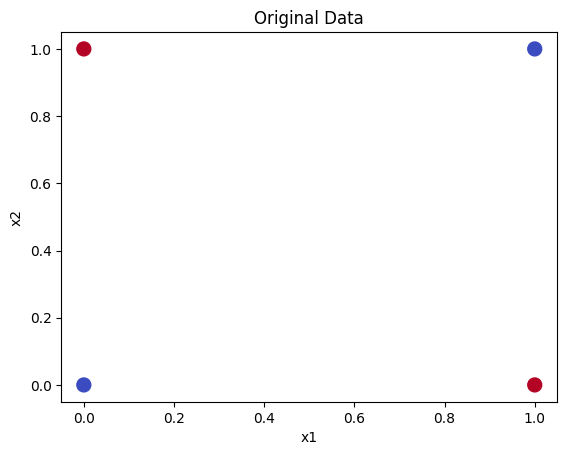

In [209]:
torch.manual_seed(801)

# manual data
X = torch.tensor([[0.,0.],
                  [1.,1.],
                  [0.,1.],
                  [1.,0.]])

y = torch.tensor([0.,0.,1.,1.]).view(-1,1) # (0,0) and (1,1) (bottom left and top right) are class 0, (0,1) and (1,0) (bottom right and top left) are class 1.

# plot the data
plt.figure()
plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap='coolwarm', s=100)
plt.title("Original Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Above we see the plot of the data, class 0 is blue and class 1 is red.  We cannot linearly separate the classes here so logistic regression and softmax regression will fail unless we do something like add a new input feature which is $x_1x_2$.  In practice, with high dimensional data, it isn't so easy to engineer a new feature like that and things get out of hand (if we have 10 features which isn't uncommon, we could need 45 (10 choose 2) pairwise terms like that).  The necessary transformation could also be something that is not so simple to figure out ($\sin(x_1x_2-\ln(x_1))$ or something like that as a random example).  So the neural network can automatically learn the transformations without requiring manual feature transformations.  When we have deeper networks (multiple hidden layers), this typically allows for even more complex transformations/representations to be made by composing simpler ones (this is typically more efficient than trying to use a single wide hidden layer, though there's a theorem that a wide enough single hidden layer can approximate almost any function).  

Now we create the model:

In [210]:
model = nn.Sequential(
    nn.Linear(2, 2), # 2 input features (x1, x2), 2 outputs (z1, z2)
    nn.Tanh(), # take hyperbolic tangent of z1 and z2 getting h1 and h2
    nn.Linear(2, 1), # takes h1 and h2 as inputs, outputs z
    nn.Sigmoid() # take sigmoid of z (we usually don't have to do this as the built in loss functions can, but for pedagogical reasons I'm leaving this)
)

nn.Sequential() lets us chain the layers together in order.  We use functions for sigmoid and Tanh as well as the Linear part we've seen before already.  Now we train the model like we've seen before.

In [211]:
criterion = nn.BCELoss() # this one doesn't apply the sigmoid
optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(5000):
    optimizer.zero_grad()

    #forward pass
    probs = model(X)

    #compute loss
    loss = criterion(probs, y)

    #backward pass
    loss.backward()
    optimizer.step() # update parameters

Now let's plot the transformed features $h_1$ and $h_2$ (refer to the layout of the neural network above).

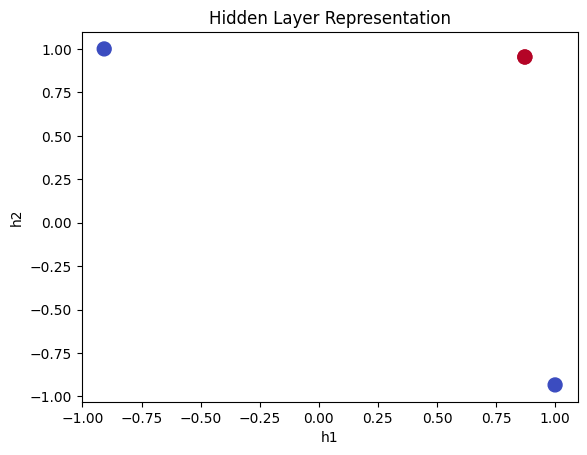

In [212]:
with torch.no_grad(): # don't want to track gradients
    hidden = torch.tanh(model[0](X)) # get h1 and h2 (take hyperbolic tangent of first layer outputs)

h = hidden.numpy() # convert to numpy to plot

plt.figure()
plt.scatter(h[:,0], h[:,1], c=y.squeeze(), cmap='coolwarm', s=100)
plt.title("Hidden Layer Representation")
plt.xlabel("h1")
plt.ylabel("h2")
plt.show()

We see that the neural network has transformed the features in a way where they are now linearly separable, so the last layer can essentially run logistic regression on them to get the probabilities and be 100% accurate here.

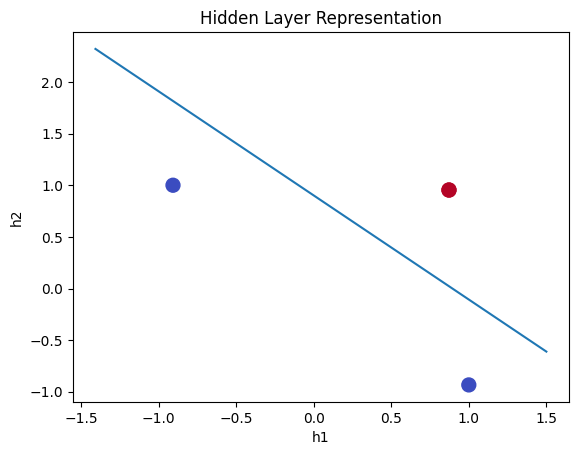

In [213]:
# extract final linear layer
W2 = model[2].weight.detach().numpy()[0]
b2 = model[2].bias.detach().numpy()[0]

# plot hidden points
plt.figure()
plt.scatter(h[:,0], h[:,1], c=y.squeeze(), cmap='coolwarm', s=100)

# plot linear boundary where W2[0]*a1 + W2[1]*a2 + b2 = 0 (when z = 0 we have p=0.5)
a1_vals = np.linspace(h[:,0].min()-0.5, h[:,0].max()+0.5, 100)
a2_vals = -(W2[0]*a1_vals + b2) / W2[1]

plt.plot(a1_vals, a2_vals)

plt.title("Hidden Layer Representation")
plt.xlabel("h1")
plt.ylabel("h2")
plt.show()

Assignment:

1. Create a neural network with two hidden layers that uses the 4 features of the Iris dataset to predict the Iris species (all 3 labels).  The first hidden layer should have 10 nodes and the second should have 3.  Use nn.ReLU() as the activation function throughout.

2. Train the model for 1000 epochs with a learning rate of $0.1$ and compute its accuracy on both the train and test data.  Use nn.CrossEntropyLoss() which automatically applies the softmax (so your model should only output logits).

3. How many parameters does the model have?

Hints: May be helpful to check the softmax regression code for some parts.

In [214]:

# load data
iris = load_iris()
X = iris['data']
y = iris['target']

# convert to tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long) # integer labels

X_train, X_test, y_train, y_test = train_test_split(X, y, seed = 108)
X_train, X_test = standardize_train_test(X_train, X_test)

# check that we have roughly equal class representation in the training data
torch.unique(y_train, return_counts = True)[1]

tensor([40, 41, 39])

In [215]:
# write your code here